# Patch clouds: generation and PCA exploration

Every `3x3` grayscale patch is a point in `R^9`. Different image
distributions (natural photographs, synthetic textures, stochastic
noise) produce patch clouds with very different geometries, and PCA is
the first tool to look at them.

In this notebook we do not cluster anything.
The goal is to see how much structure lives in each patch cloud, so that downstream notebooks
(`07_patch_stratification.ipynb`) can pick the right filtrations


In [1]:
from pathlib import Path

import numpy as np                                                                                                                                                                                                  
import matplotlib.pyplot as plt
from PIL import Image                                                                                                                                                                                               
from skimage import transform
from sklearn.decomposition import PCA
from sklearn.feature_extraction.image import extract_patches_2d                                                                                                                                                     

FIG = Path("figures")                                                                                                                                                                                               
FIG.mkdir(exist_ok=True)
DATA = Path("data")   

## Source images

Seven 96x96 grayscale images spanning three regimes:

natural: `house`, `tissue` (loaded from `data/`)

synthetic structured: `stripes` (horizontal cosine),
  `checker` (8x8 squares), `gauss_blob` (smooth radial Gaussian)

stochastic: `white_noise` (iid Gaussian) and
  `pink_noise` (1/f via FFT shaping of iid Gaussian)


In [ ]:
def load_gray(path, size=96):
    img = np.asarray(Image.open(path).convert("L"), dtype=float) / 255.0
    return transform.resize(img, (size, size), anti_aliasing=True)


SIZE = 96
_yy, _xx = np.mgrid[0:SIZE, 0:SIZE]


def make_stripes(k=6):
    return 0.5 + 0.5 * np.cos(2 * np.pi * k * _yy / SIZE)


def make_checker(squares=8):
    s = SIZE // squares
    return ((_yy // s + _xx // s) % 2).astype(float)


def make_gauss_blob(sigma=24):
    c = SIZE / 2
    return np.exp(-(((_yy - c) ** 2 + (_xx - c) ** 2) / (2 * sigma ** 2)))


def make_white_noise(rng):
    return rng.normal(0.5, 0.15, (SIZE, SIZE)).clip(0, 1)


def make_pink_noise(rng, alpha=1.0):
    F = np.fft.fft2(rng.randn(SIZE, SIZE))
    fy = np.fft.fftfreq(SIZE)[:, None]
    fx = np.fft.fftfreq(SIZE)[None, :]
    mag = np.sqrt(fy ** 2 + fx ** 2)
    mag[0, 0] = 1.0
    F = F / (mag ** (alpha / 2))
    img = np.real(np.fft.ifft2(F))
    return (img - img.min()) / (img.max() - img.min())


IMAGES = {
    "house": load_gray(DATA / "house.png"),
    "tissue": load_gray(DATA / "tissue.png"),
    "stripes": make_stripes(),
    "checker": make_checker(),
    "gauss_blob": make_gauss_blob(),
    "white_noise": make_white_noise(np.random.RandomState(0)),
    "pink_noise": make_pink_noise(np.random.RandomState(1), alpha=1.0),
}

CMAP = plt.get_cmap("tab10")
COLOURS = {name: CMAP(i) for i, name in enumerate(IMAGES)}

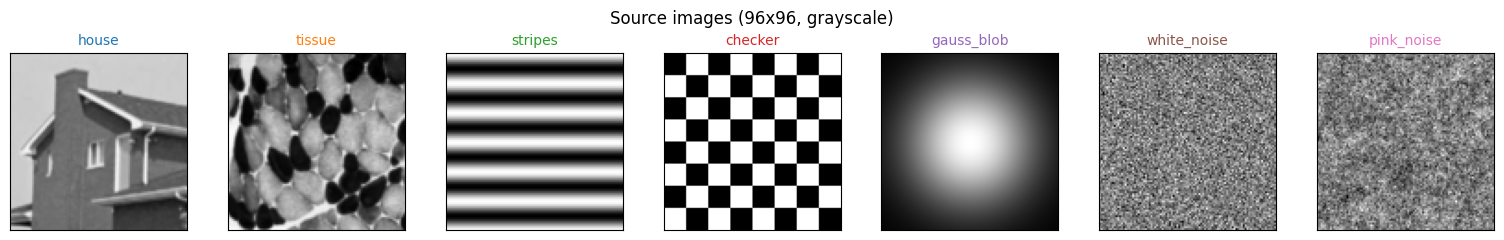

In [ ]:
fig, axes = plt.subplots(1, len(IMAGES), figsize=(2.2 * len(IMAGES), 2.4),
                         squeeze=False)
for ax, (name, img) in zip(axes[0], IMAGES.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(name, fontsize=10, color=COLOURS[name])
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Source images (96x96, grayscale)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "patch_sources.png", dpi=150, bbox_inches="tight")
plt.show()

## Patch extraction

For each image we collect every `3x3` patch and flatten it
to a 9-vector, then subtract the per-patch mean to remove the
brightness component and keep pure contrast information. This is
exactly the preprocessing used in Lee–Mumford–Pedersen and in
notebook 07.


In [6]:
def patches_of(img):
    return extract_patches_2d(img, (3, 3)).reshape(-1, 9).astype(float)


PATCHES_RAW = {k: patches_of(v) for k, v in IMAGES.items()}
PATCHES = {k: X - X.mean(axis=1, keepdims=True)
           for k, X in PATCHES_RAW.items()}
NORMS = {k: np.linalg.norm(X, axis=1) for k, X in PATCHES.items()}

### What patches actually look like

To ground the PCA analysis below: eight random patches from each source (left column) next to the eight patches with largest centered l2-norm (right column)

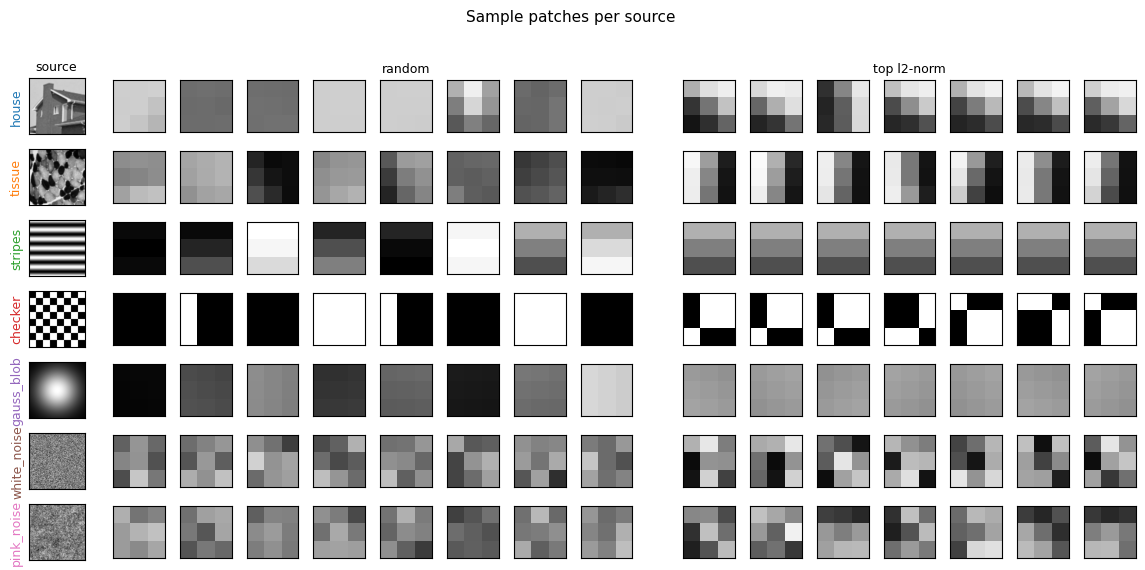

In [8]:
n_show = 8
rng = np.random.RandomState(0)
fig, axes = plt.subplots(len(IMAGES), 2 * n_show + 1,
                         figsize=(0.6 * (2 * n_show + 1) + 1.4,
                                  0.8 * len(IMAGES)),
                         squeeze=False,
                         gridspec_kw={"width_ratios": [1.6] + [1] * n_show
                                      + [0.4] + [1] * (n_show - 1)})
for r, (name, X_raw) in enumerate(PATCHES_RAW.items()):
    norms = NORMS[name]
    axes[r, 0].imshow(IMAGES[name], cmap="gray", vmin=0, vmax=1)
    axes[r, 0].set_ylabel(name, fontsize=9, color=COLOURS[name])
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    if r == 0:
        axes[r, 0].set_title("source", fontsize=9)

    idx_rand = rng.choice(len(X_raw), n_show, replace=False)
    for j in range(n_show):
        axes[r, 1 + j].imshow(X_raw[idx_rand[j]].reshape(3, 3),
                              cmap="gray", vmin=0, vmax=1)
        axes[r, 1 + j].set_xticks([]); axes[r, 1 + j].set_yticks([])
        if r == 0 and j == n_show // 2:
            axes[r, 1 + j].set_title("random", fontsize=9)

    axes[r, n_show + 1].axis("off")

    idx_top = np.argsort(norms)[-n_show + 1:][::-1]
    for j, pi in enumerate(idx_top):
        axes[r, n_show + 2 + j].imshow(X_raw[pi].reshape(3, 3),
                                       cmap="gray", vmin=0, vmax=1)
        axes[r, n_show + 2 + j].set_xticks([])
        axes[r, n_show + 2 + j].set_yticks([])
        if r == 0 and j == (n_show - 1) // 2:
            axes[r, n_show + 2 + j].set_title("top l2-norm", fontsize=9)
fig.suptitle("Sample patches per source",
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(FIG / "patch_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## PCA on the full patch cloud

Fit a PCA with 9 components on each cloud


In [9]:
PCAS = {k: PCA(n_components=9, random_state=0).fit(X)
        for k, X in PATCHES.items()}

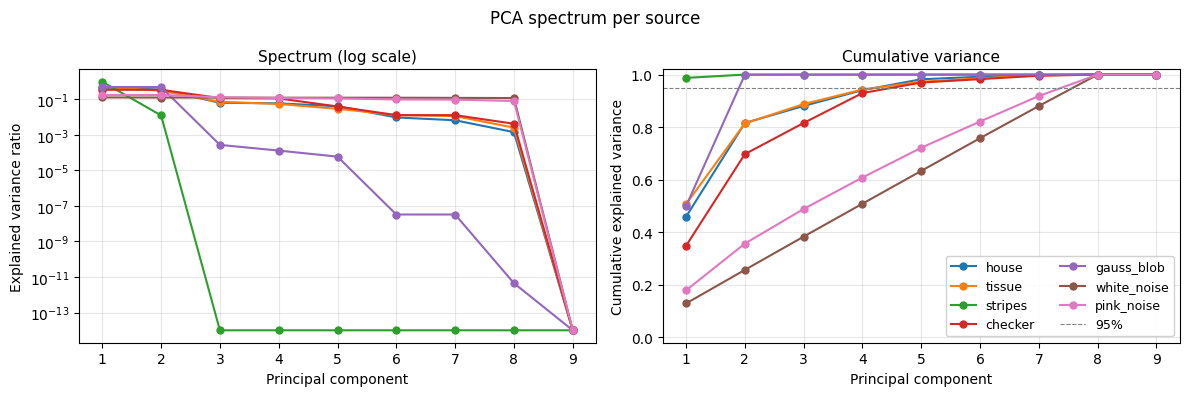

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.0))
for name, pca in PCAS.items():
    evr = pca.explained_variance_ratio_
    ax1.plot(np.arange(1, 10), np.clip(evr, 1e-14, None),
             "-o", label=name, color=COLOURS[name], markersize=5,
             linewidth=1.5)
    ax2.plot(np.arange(1, 10), np.cumsum(evr), "-o", label=name,
             color=COLOURS[name], markersize=5, linewidth=1.5)
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_yscale("log"); ax1.grid(alpha=0.3, which="both")
ax1.set_title("Spectrum (log scale)", fontsize=11)
ax2.set_xlabel("Principal component")
ax2.set_ylabel("Cumulative explained variance")
ax2.axhline(0.95, color="gray", ls="--", lw=0.8, label="95%")
ax2.grid(alpha=0.3); ax2.set_ylim(-0.02, 1.02)
ax2.set_title("Cumulative variance", fontsize=11)
ax2.legend(loc="lower right", fontsize=9, ncol=2, framealpha=0.9)
fig.suptitle("PCA spectrum per source",
             fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "patch_pca_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()


## Principal components as `3x3` images

Each eigenvector lives in `R^9` so we reshape it back to a `3x3` kernel.

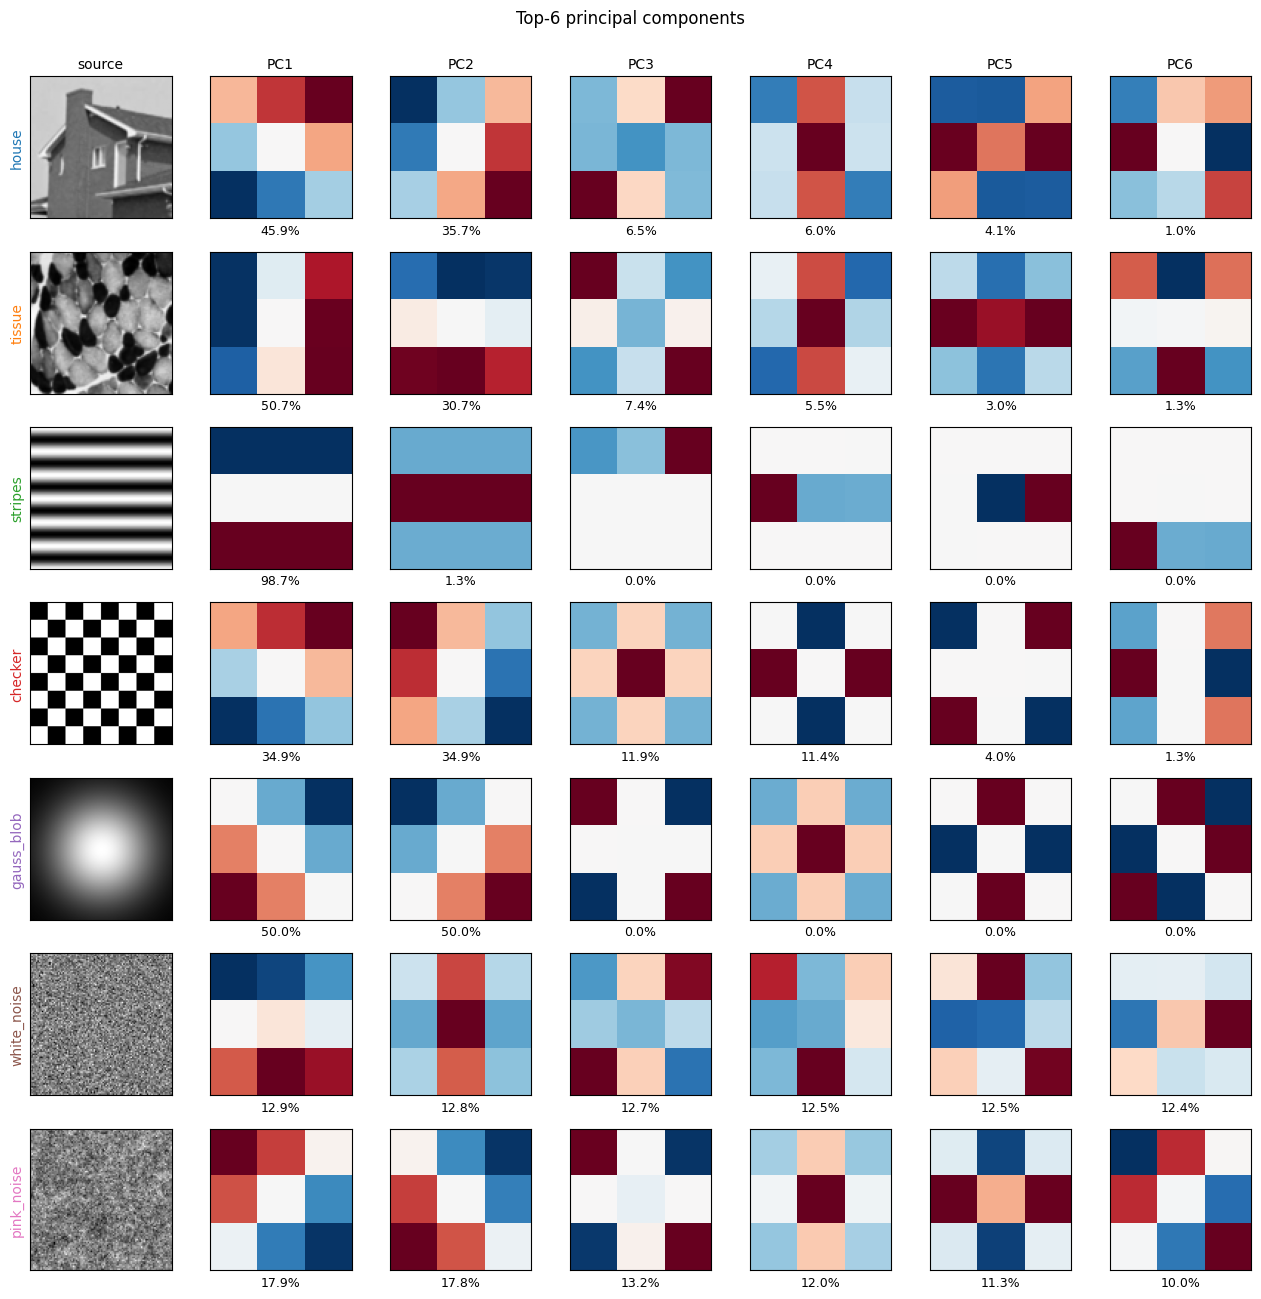

In [13]:
def plot_pc_grid(pcas, images, path, title, n_pc=6):
    fig, axes = plt.subplots(len(pcas), n_pc + 1,
                             figsize=(1.85 * (n_pc + 1),
                                      1.85 * len(pcas)),
                             squeeze=False)
    for r, (name, pca) in enumerate(pcas.items()):
        axes[r, 0].imshow(images[name], cmap="gray", vmin=0, vmax=1)
        axes[r, 0].set_ylabel(name, fontsize=10, color=COLOURS[name])
        if r == 0:
            axes[r, 0].set_title("source", fontsize=10)
        for k in range(n_pc):
            v = pca.components_[k].reshape(3, 3)
            m = max(np.abs(v).max(), 1e-12)
            axes[r, k + 1].imshow(v, cmap="RdBu_r", vmin=-m, vmax=m)
            if r == 0:
                axes[r, k + 1].set_title(f"PC{k + 1}", fontsize=10)
            evr = pca.explained_variance_ratio_[k]
            axes[r, k + 1].set_xlabel(f"{evr * 100:.1f}%", fontsize=9)
        for ax in axes[r]:
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, fontsize=12, y=1.00)
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

plot_pc_grid(PCAS, IMAGES, FIG / "patch_pcs.png",
             "Top-6 principal components")

## PC1 vs PC2 scatter (raw cloud)

Project each cloud onto its own top 2 components

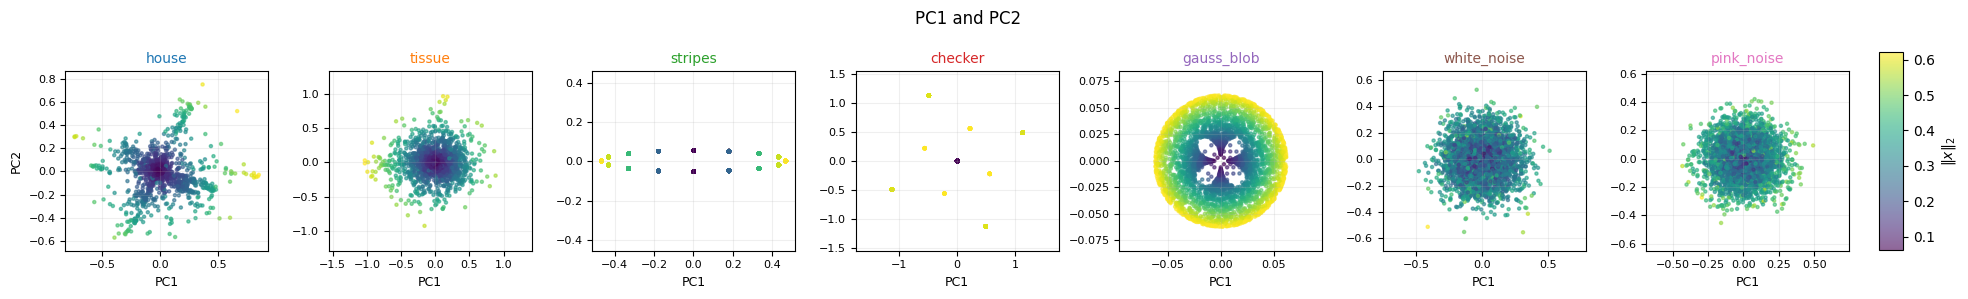

In [16]:
def plot_pc12_scatter(patches, norms, pcas, path, title,
                      max_points=3000, colours=None):
    colours = colours or COLOURS
    n = len(pcas)
    fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.0), squeeze=False)
    rng = np.random.RandomState(0)
    sc = None
    for ax, (name, pca) in zip(axes[0], pcas.items()):
        X = patches[name]
        m = min(max_points, len(X))
        idx = rng.choice(len(X), m, replace=False)
        Xp = pca.transform(X[idx])
        nrm = norms[name][idx]
        sc = ax.scatter(Xp[:, 0], Xp[:, 1], c=nrm, cmap="viridis",
                        s=5, alpha=0.6)
        ax.set_title(name, fontsize=10, color=colours[name])
        ax.set_xlabel("PC1", fontsize=9)
        ax.set_ylabel("PC2" if ax is axes[0, 0] else "", fontsize=9)
        ax.set_aspect("equal", "datalim")
        ax.tick_params(labelsize=8)
        ax.grid(alpha=0.2)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.96, 1])
    cax = fig.add_axes([0.965, 0.18, 0.012, 0.66])
    fig.colorbar(sc, cax=cax, label=r"$\|x\|_2$")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


plot_pc12_scatter(PATCHES, NORMS, PCAS,
                  FIG / "patch_pc12_scatter.png",
                  "PC1 and PC2")

## Top-contrast patches only (Lee-Mumford-Pedersen filter)

Most patches in a natural image are almost flat (sky, solid walls,
uniform surfaces). They cluster near the origin of `R^9` and dominate
the raw PCA. The classical Lee-Mumford-Pedersen trick is to keep only
the top 20% by l2-norm. This strips away the flat core and
exposes the edge manifold structure. We fit PCA on this high-contrast
subset per source.

In [ ]:
def top_contrast(X, norms, frac=0.20):
    thr = np.quantile(norms, 1 - frac)
    mask = norms >= thr
    return X[mask], mask


PATCHES_HC, NORMS_HC, PCAS_HC = {}, {}, {}
for name, X in PATCHES.items():
    X_hc, mask = top_contrast(X, NORMS[name], frac=0.20)
    PATCHES_HC[name] = X_hc
    NORMS_HC[name] = NORMS[name][mask]
    PCAS_HC[name] = PCA(n_components=9, random_state=0).fit(X_hc)

cols = ["source", "kept/total", "PC1% raw", "PC1% hc"]
w = max(max(len(c) for c in cols), max(len(n) for n in PATCHES)) + 2
print("".join(f"{c:>{w}}" for c in cols))
for name in PATCHES:
    evr_r = PCAS[name].explained_variance_ratio_
    evr_h = PCAS_HC[name].explained_variance_ratio_
    row = [
        name,
        f"{len(PATCHES_HC[name])}/{len(PATCHES[name])}",
        f"{evr_r[0] * 100:.1f}",
        f"{evr_h[0] * 100:.1f}",
    ]
    print("".join(f"{c:>{w}}" for c in row))

       source   kept/total     PC1% raw      PC1% hc
        house    1768/8836         45.9         47.4
       tissue    1768/8836         50.7         52.7
      stripes    1786/8836         98.7         99.9
      checker    2436/8836         34.9         34.9
   gauss_blob    1768/8836         50.0         50.0
  white_noise    1768/8836         12.9         13.5
   pink_noise    1768/8836         17.9         20.7


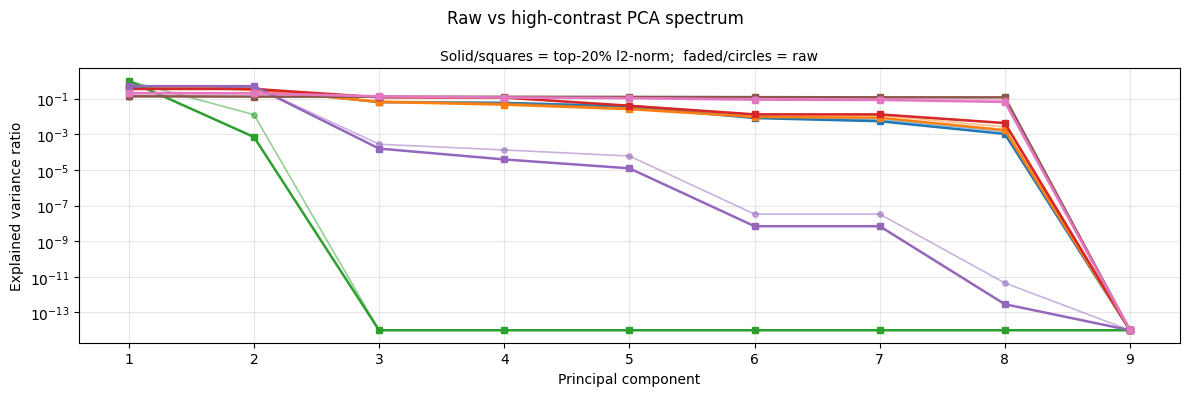

In [22]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 4.0))
for name in PATCHES:
    evr_r = PCAS[name].explained_variance_ratio_
    evr_h = PCAS_HC[name].explained_variance_ratio_
    ax1.plot(np.arange(1, 10), np.clip(evr_r, 1e-14, None),
             "-o", color=COLOURS[name], alpha=0.5, markersize=4,
             linewidth=1.2, label=None)
    ax1.plot(np.arange(1, 10), np.clip(evr_h, 1e-14, None),
             "-s", color=COLOURS[name], markersize=5, linewidth=1.8,
             label=name)
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_yscale("log"); ax1.grid(alpha=0.3, which="both")
ax1.set_title("Solid/squares = top-20% l2-norm;  "
              "faded/circles = raw", fontsize=10)

names = list(PATCHES)
x = np.arange(len(names))
fig.suptitle("Raw vs high-contrast PCA spectrum", fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "patch_pca_spectrum_hc.png", dpi=150,
            bbox_inches="tight")
plt.show()


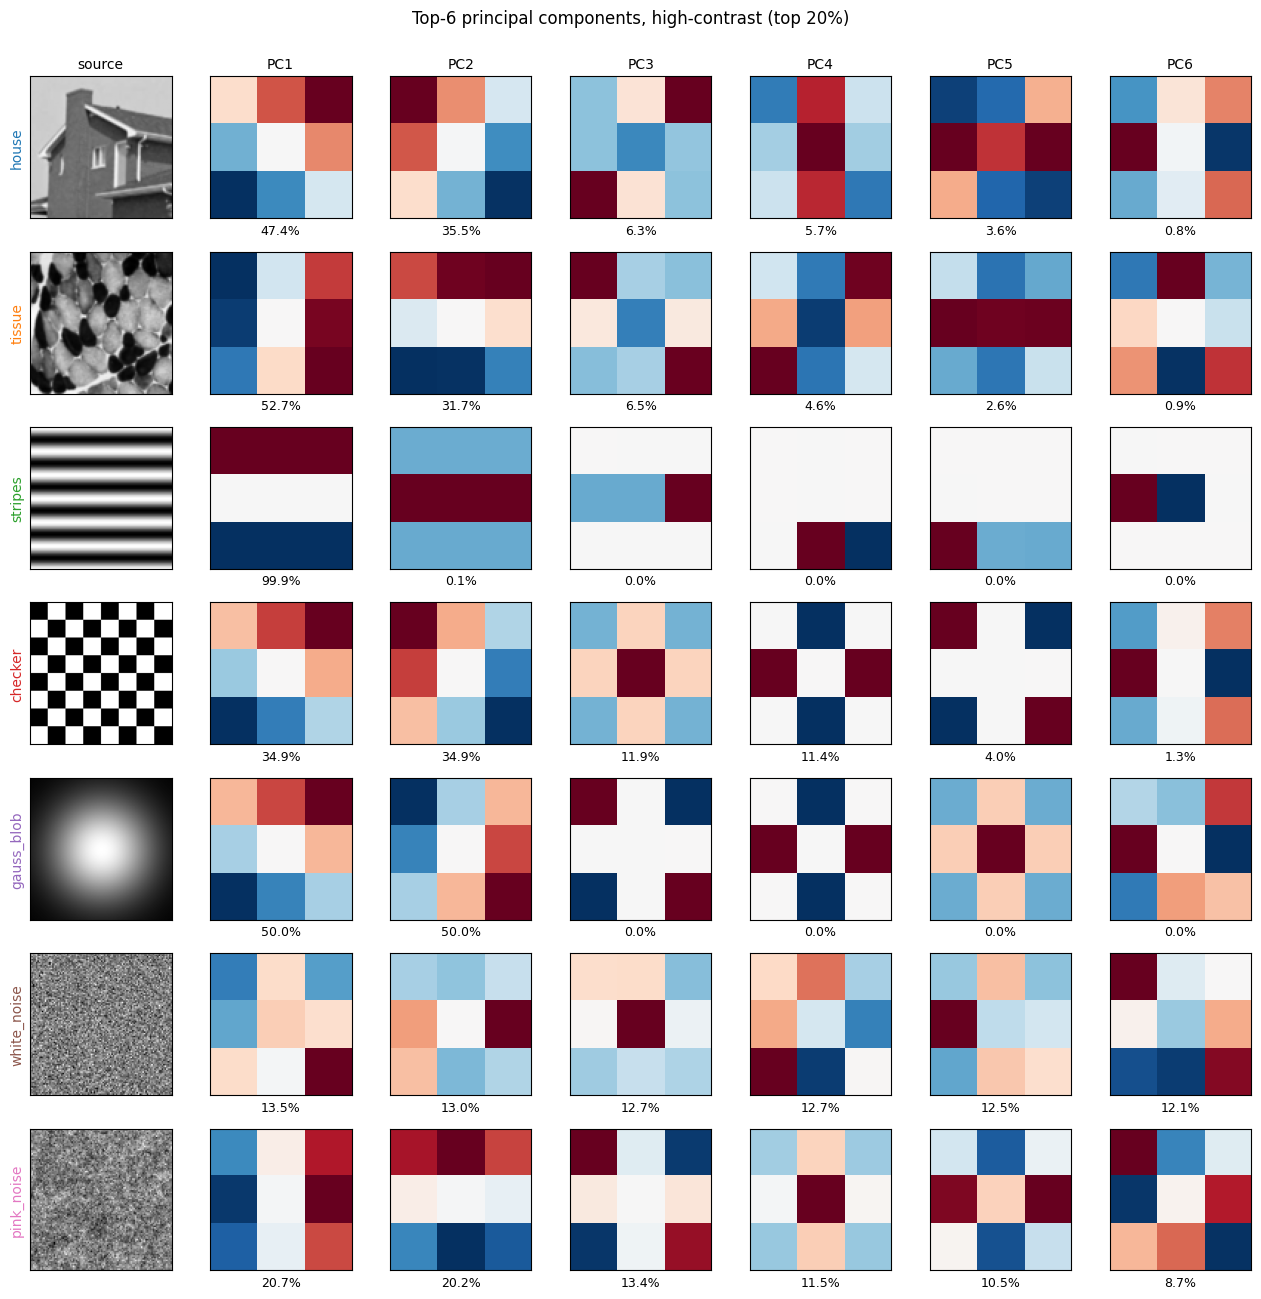

In [23]:
plot_pc_grid(PCAS_HC, IMAGES, FIG / "patch_pcs_hc.png",
             "Top-6 principal components, high-contrast (top 20%)")

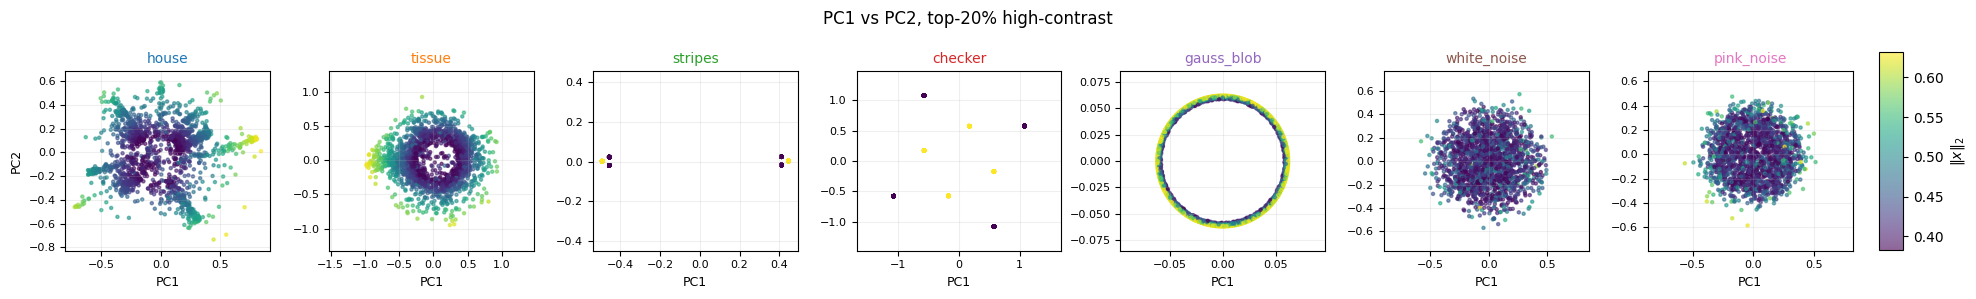

In [24]:
plot_pc12_scatter(PATCHES_HC, NORMS_HC, PCAS_HC,
                  FIG / "patch_pc12_scatter_hc.png",
                  "PC1 vs PC2, top-20% high-contrast")


## Calibration: synthetic R^9 distributions


A participation-ratio of `2.8` for tissue means nothing on its own. To anchor it, we compute PR on three reference clouds in R^9 where the true intrinsic dimension is known by construction:

`iid_gauss_9d`: `N(0, I_9)` samples. No structure at all. After per-sample mean-centring, rank drops to 8 and PR should land at 8.

`low_rank_3`: 3D Gaussian rotated into R^9 via a random orthonormal embedding, plus $\sigma$ = 0.05 noise. True rank 3, PR $\approx$ 3.

`line_9d`: points along `t * v` for a random unit vector `v`, $\sigma$ = 0.05 transverse noise. True rank 1, PR $\approx$ 1.


2000 samples each, mean-centred per sample so the rank-8 ceiling applies to everyone uniformly (centring kills one dimension; nothing escapes that).

Once we have these anchors, we can read the natural-image PRs as positions on a known scale instead of bare numbers.


In [26]:
def gen_iid_gauss(n=2000, rng=None):
    rng = rng or np.random.RandomState(42)
    return rng.normal(0, 1, (n, 9))

def participation_ratio(evr):                                                                                                                                                                                       
    evr = np.asarray(evr, dtype=float)
    if evr.sum() == 0:                                                                                                                                                                                              
        return 0.0   
    return float(evr.sum() ** 2 / np.sum(evr ** 2))
                                                                                                                                                                                                                      
                                                                                                                                                                                                                      
def kaiser95_dim(evr, threshold=0.95):                                                                                                                                                                              
    return int(np.searchsorted(np.cumsum(evr), threshold) + 1)  

def gen_low_rank(n=2000, r=3, noise=0.05, rng=None):
    rng = rng or np.random.RandomState(43)
    Q, _ = np.linalg.qr(rng.normal(0, 1, (9, r)))
    Z = rng.normal(0, 1, (n, r))
    return Z @ Q.T + rng.normal(0, noise, (n, 9))


def gen_line(n=2000, noise=0.05, rng=None):
    rng = rng or np.random.RandomState(44)
    v = rng.normal(0, 1, 9); v /= np.linalg.norm(v)
    t = rng.normal(0, 1, (n, 1))
    return t * v[None, :] + rng.normal(0, noise, (n, 9))


SYN_SPECS = {
    "iid_gauss_9d": gen_iid_gauss(),
    "low_rank_3": gen_low_rank(r=3),
    "line_9d": gen_line(),
}
SYN_PATCHES = {k: X - X.mean(axis=1, keepdims=True)
               for k, X in SYN_SPECS.items()}
SYN_NORMS = {k: np.linalg.norm(X, axis=1) for k, X in SYN_PATCHES.items()}
SYN_PCAS = {k: PCA(n_components=9, random_state=0).fit(X)
            for k, X in SYN_PATCHES.items()}
SYN_COLOURS = {
    "iid_gauss_9d": "#555555",
    "low_rank_3": "#117733",
    "line_9d": "#AA3377",
}

cols = ["source", "n", "PR", "dim95", "PC1 %"]
w = max(max(len(c) for c in cols), max(len(n) for n in SYN_PCAS)) + 2
print("".join(f"{c:>{w}}" for c in cols))
for k, pca in SYN_PCAS.items():
    evr = pca.explained_variance_ratio_
    row = [k, str(len(SYN_PATCHES[k])),
           f"{participation_ratio(evr):.2f}",
           str(kaiser95_dim(evr)),
           f"{evr[0] * 100:.1f}"]
    print("".join(f"{c:>{w}}" for c in row))

        source             n            PR         dim95         PC1 %
  iid_gauss_9d          2000          7.97             8          13.7
    low_rank_3          2000          2.76             3          42.4
       line_9d          2000          1.03             1          98.3


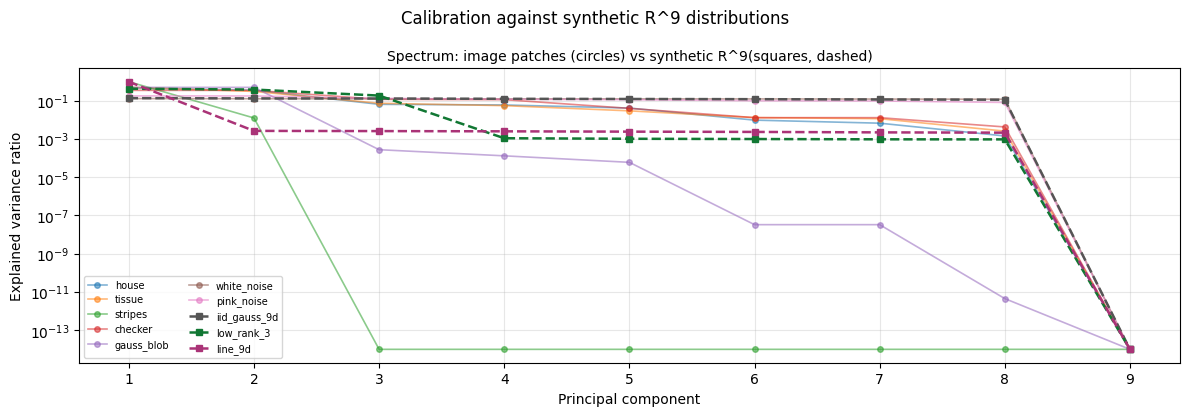

In [28]:
fig, ax1 = plt.subplots(1, 1, figsize=(12, 4.2))

for name, pca in PCAS.items():
    ax1.plot(np.arange(1, 10),
             np.clip(pca.explained_variance_ratio_, 1e-14, None),
             "-o", color=COLOURS[name], alpha=0.55,
             markersize=4, linewidth=1.2, label=name)
for name, pca in SYN_PCAS.items():
    ax1.plot(np.arange(1, 10),
             np.clip(pca.explained_variance_ratio_, 1e-14, None),
             "--s", color=SYN_COLOURS[name], markersize=5,
             linewidth=1.8, label=name)
ax1.set_yscale("log")
ax1.grid(alpha=0.3, which="both")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Spectrum: image patches (circles) vs synthetic R^9"
              "(squares, dashed)", fontsize=10)
ax1.legend(fontsize=7, ncol=2, loc="lower left")

all_names = list(PATCHES) + list(SYN_PATCHES)
all_prs = ([participation_ratio(PCAS[n].explained_variance_ratio_)
            for n in PATCHES]
           + [participation_ratio(SYN_PCAS[n].explained_variance_ratio_)
              for n in SYN_PATCHES])
all_cols = ([COLOURS[n] for n in PATCHES]
            + [SYN_COLOURS[n] for n in SYN_PATCHES])

fig.suptitle("Calibration against synthetic R^9 distributions",
             fontsize=12)
fig.tight_layout()
fig.savefig(FIG / "patch_pca_calibration.png", dpi=150,
            bbox_inches="tight")
plt.show()

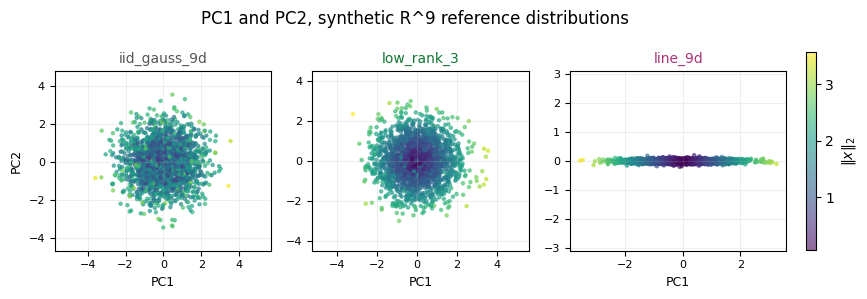

In [29]:
plot_pc12_scatter(SYN_PATCHES, SYN_NORMS, SYN_PCAS,
                  FIG / "patch_pc12_scatter_synthetic.png",
                  "PC1 and PC2, synthetic R^9 reference distributions",
                  colours={**COLOURS, **SYN_COLOURS})

### Calibration: takeaway.

white_noise ~ iid_gauss_9d (PR ~ 8) - confirmed pure noise.

stripes ~ line_9d (PR ~ 1) - 1-parameter patch family.

house, tissue (PR ~ 2.8-2.9) ~ low_rank_3 (PR ~ 2.75) - natural patches live on an effectively 3D linear manifold (Lee-Mumford-Pedersen edge manifold + flat core).

PC1-PC2 scatter agrees: noise is an isotropic blob, low_rank_3 is a 2D ellipse, line is a strip. 